通过使用不同种类的分类器，降低结果之间的相关性

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

In [7]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. 定义多个基础分类器
clf1 = LogisticRegression(random_state=42)
clf2 = SVC(probability=True, random_state=42)
clf3 = DecisionTreeClassifier(max_depth=5, random_state=42)

# 3. 构建投票集成分类器
# voting='hard' 硬投票；voting='soft' 软投票
voting_clf = VotingClassifier(
    estimators=[
        ('lr', clf1),
        ('svc', clf2),
        ('tree', clf3)
    ],
    voting='soft'
)

# 4. 训练
voting_clf.fit(X_train, y_train)

# 5. 分别输出单个模型与集成模型精度
for name, clf in voting_clf.named_estimators_.items():
    y_pred = clf.predict(X_test)
    print(f"{name} 测试准确率: {accuracy_score(y_test, y_pred):.4f}")

y_pred_vote = voting_clf.predict(X_test)
print(f"\n投票分类器 测试准确率: {accuracy_score(y_test, y_pred_vote):.4f}")


lr 测试准确率: 0.8767
svc 测试准确率: 0.9767
tree 测试准确率: 0.9567

投票分类器 测试准确率: 0.9667


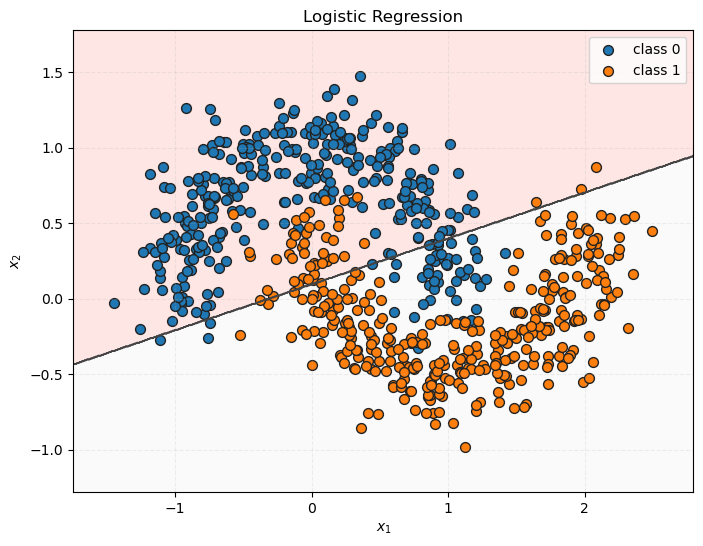

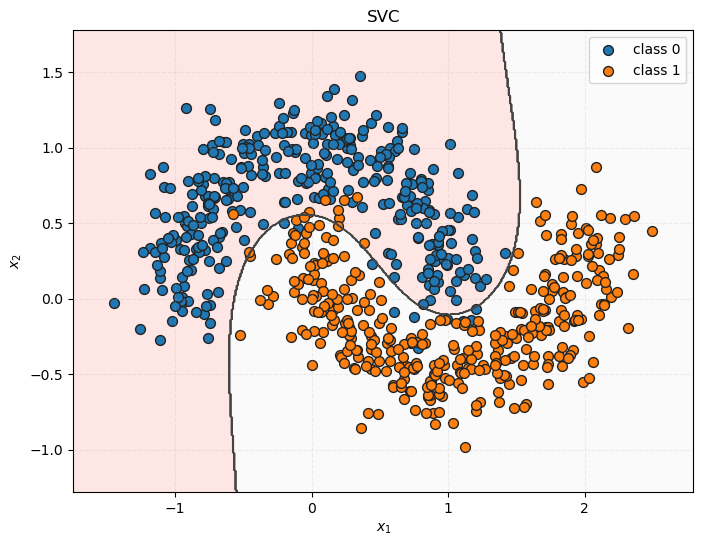

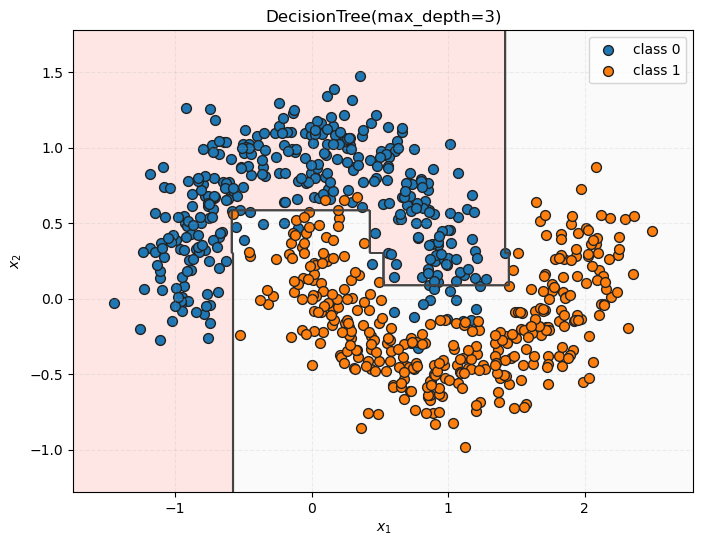

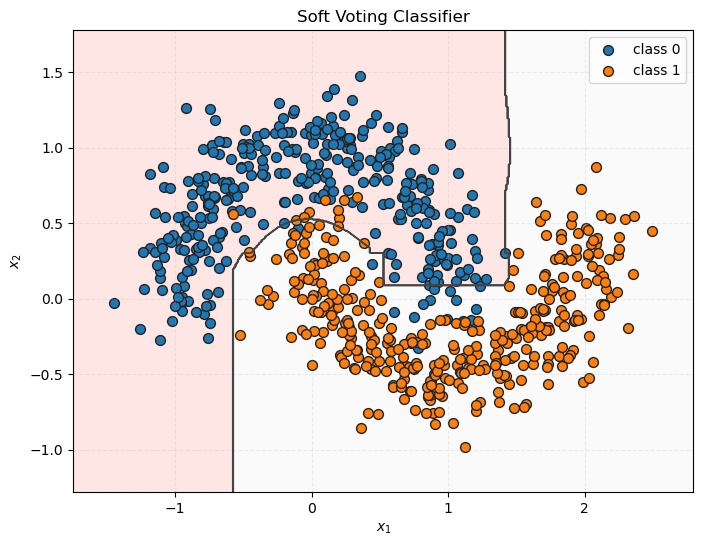

In [9]:
def plot_decision_boundary(clf, X, y, title):
    plt.figure(figsize=(8,6))
    x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
    x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3
    xx0, xx1 = np.meshgrid(np.linspace(x0_min, x0_max, 500),
                           np.linspace(x1_min, x1_max, 500))
    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = clf.predict(grid).reshape(xx0.shape)

    plt.contourf(xx0, xx1, pred, alpha=0.32, cmap="Pastel1")
    plt.contour(xx0, xx1, pred, colors="#444444", linewidths=0.75)

    # 画出样本
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(X[mask,0], X[mask,1], s=50, edgecolors="#222222", label=f"class {label}")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2, linestyle="--")
    plt.show()

# 依次画出单个模型 + 投票集成
plot_decision_boundary(voting_clf.named_estimators_["lr"], X_train, y_train, "Logistic Regression")
plot_decision_boundary(voting_clf.named_estimators_["svc"], X_train, y_train, "SVC")
plot_decision_boundary(voting_clf.named_estimators_["tree"], X_train, y_train, "DecisionTree(max_depth=3)")
plot_decision_boundary(voting_clf, X_train, y_train, "Soft Voting Classifier")